# Project Objectives

1. To develop a machine learning model capable of predicting loan approval status based on applicant financial and demographic information.

2. To perform data cleaning, preprocessing, and transformation on the loan prediction dataset for effective model training.

3. To conduct exploratory data analysis (EDA) in order to identify patterns, trends, and relationships between customer features and loan approval outcomes.

4. To train and compare multiple machine learning classification algorithms such as Logistic Regression, Decision Tree, Random Forest, and XGBoost.

5. To evaluate model performance using classification metrics including Accuracy, Precision, Recall, F1-score, ROC-AUC, and Confusion Matrix.

6. To identify the most important factors influencing loan approval decisions through feature importance and explainability techniques.

7. To save and prepare the trained machine learning model for deployment and real-world usage.

8. To build a simple FastAPI-based prediction API capable of serving real-time loan approval predictions.

9. To demonstrate an end-to-end industry-standard machine learning workflow from data preprocessing to deployment preparation.

10. To develop practical skills in machine learning engineering, model evaluation, and AI system deployment.


# IMPORT LIBRARIES

In [57]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn preprocessing
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# Train test split
from sklearn.model_selection import train_test_split

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier 
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
from xgboost import XGBClassifier

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
) 

#saving model
import joblib

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# LOAD DATASET

In [4]:
df=pd.read_csv('/Users/obi/Downloads/Loan Approval.csv')

In [5]:
# Display first 5 rows
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [6]:
# Dataset shape
df.shape

(614, 13)

In [7]:
# Display columns
df.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

# FEATURE EXPLANATION (VERY IMPORTANT)

| Feature           | Meaning                 |
| ----------------- | ----------------------- |
| Gender            | Applicant gender        |
| Married           | Marital status          |
| Dependents        | Number of dependents    |
| Education         | Graduate or not         |
| Self_Employed     | Employment status       |
| ApplicantIncome   | Applicant salary        |
| CoapplicantIncome | Co-applicant salary     |
| LoanAmount        | Requested loan          |
| Loan_Amount_Term  | Loan repayment duration |
| Credit_History    | Past credit behavior    |
| Property_Area     | Urban/Semiurban/Rural   |
| Loan_Status       | Target variable         |


In [8]:
# Check data types
df.dtypes

Loan_ID               object
Gender                object
Married               object
Dependents            object
Education             object
Self_Employed         object
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area         object
Loan_Status           object
dtype: object

In [9]:
# Missing values
df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [10]:
# Check duplicate rows
df.duplicated().sum()

np.int64(0)

# TARGET CLASS DISTRIBUTION (EDA)

In [11]:
# Target distribution
df['Loan_Status'].value_counts()

Loan_Status
Y    422
N    192
Name: count, dtype: int64

## Visualization:

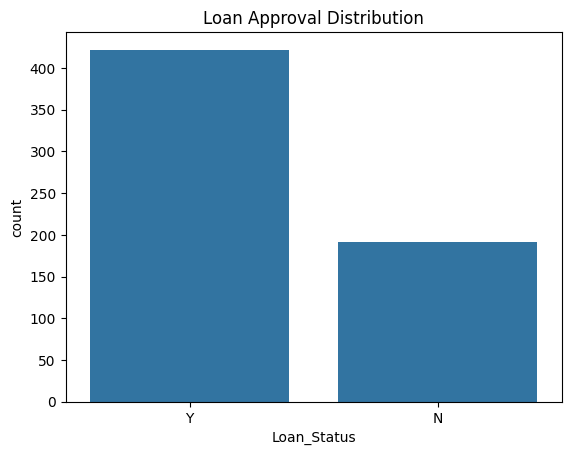

In [12]:
sns.countplot(x='Loan_Status', data=df)

plt.title("Loan Approval Distribution")
plt.show()

## INCOME DISTRIBUTION

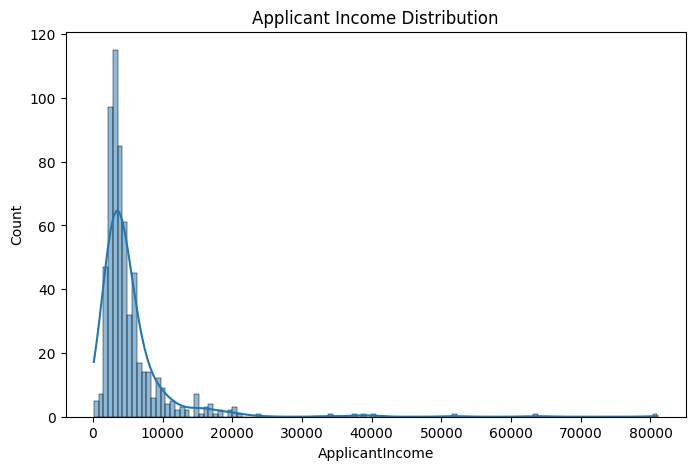

In [13]:
plt.figure(figsize=(8,5))

sns.histplot(df['ApplicantIncome'], kde=True)

plt.title("Applicant Income Distribution")
plt.show()

## LOAN AMOUNT DISTRIBUTION

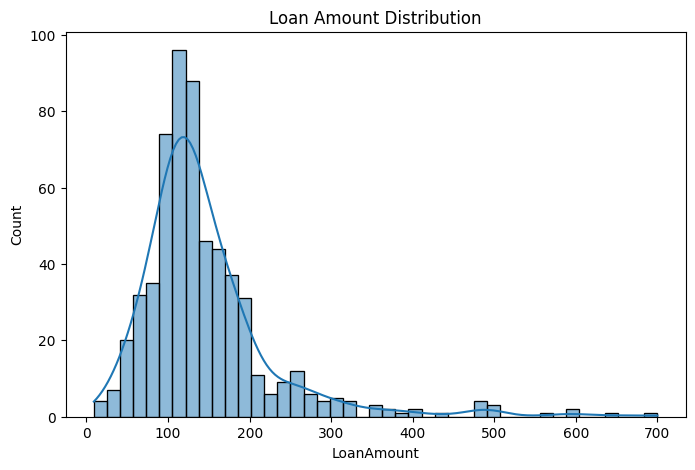

In [14]:
plt.figure(figsize=(8,5))

sns.histplot(df['LoanAmount'], kde=True)

plt.title("Loan Amount Distribution")
plt.show()

## CREDIT HISTORY ANALYSIS

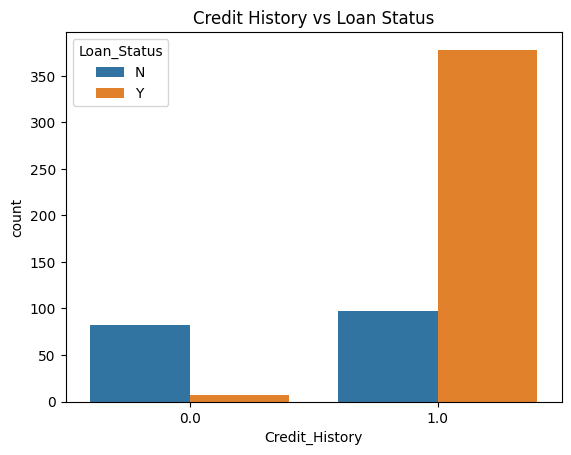

In [15]:
sns.countplot(x='Credit_History', hue='Loan_Status', data=df)

plt.title("Credit History vs Loan Status")
plt.show()

## PROPERTY AREA

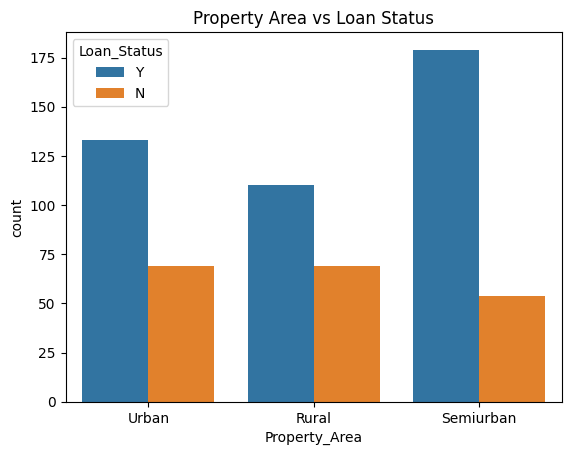

In [16]:
sns.countplot(x='Property_Area', hue='Loan_Status', data=df)

plt.title("Property Area vs Loan Status")
plt.show()

## CORRELATION ANALYSIS

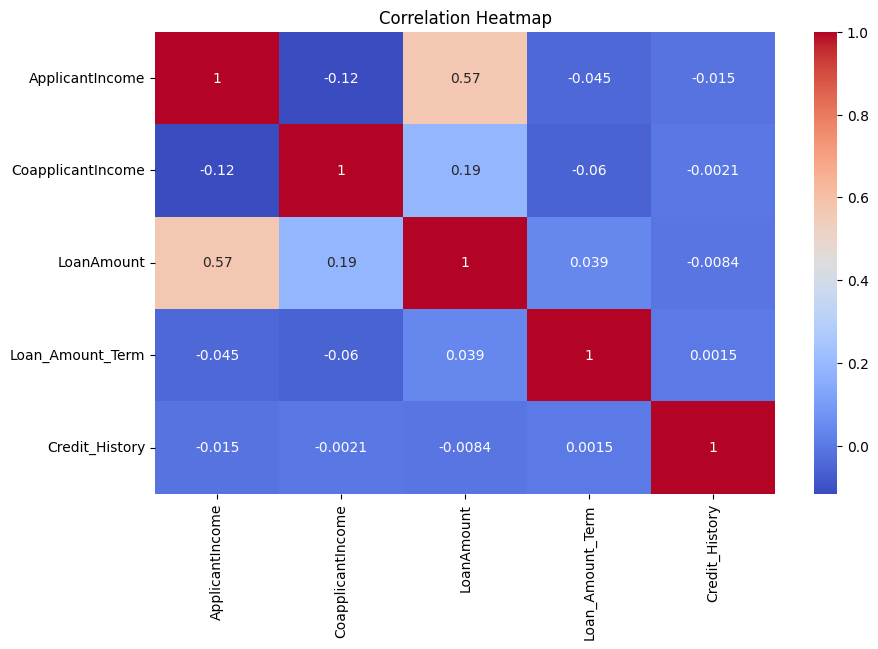

In [17]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,6))

sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()


# HANDLE MISSING VALUES


In [18]:
# Categorical columns
categorical_cols = [
    'Gender',
    'Married',
    'Dependents',
    'Self_Employed'
]

# Numerical columns
numerical_cols = [
    'LoanAmount',
    'Loan_Amount_Term',
    'Credit_History'
] 

# Fill categorical columns with mode
for col in categorical_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

# Fill numerical columns with median
for col in numerical_cols:
    df[col].fillna(df[col].median(), inplace=True)

# ENCODE CATEGORICAL VARIABLES

In [19]:
# Display categorical columns
df.select_dtypes(include='object').columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'Property_Area', 'Loan_Status'],
      dtype='object')

### ENCODE CATEGORICAL VARIABLES

In [20]:
# Create LabelEncoder object
le = LabelEncoder()

# Encode categorical columns
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

In [21]:
#verify encoding
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,0,1,0,0,0,0,5849,0.0,128.0,360.0,1.0,2,1
1,1,1,1,1,0,0,4583,1508.0,128.0,360.0,1.0,0,0
2,2,1,1,0,0,1,3000,0.0,66.0,360.0,1.0,2,1
3,3,1,1,0,1,0,2583,2358.0,120.0,360.0,1.0,2,1
4,4,1,0,0,0,0,6000,0.0,141.0,360.0,1.0,2,1


# OUTLIER VISUALIZATION

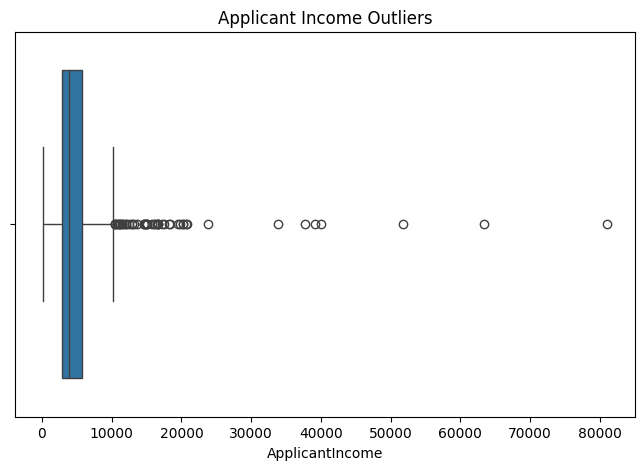

In [22]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df['ApplicantIncome'])

plt.title("Applicant Income Outliers")
plt.show()

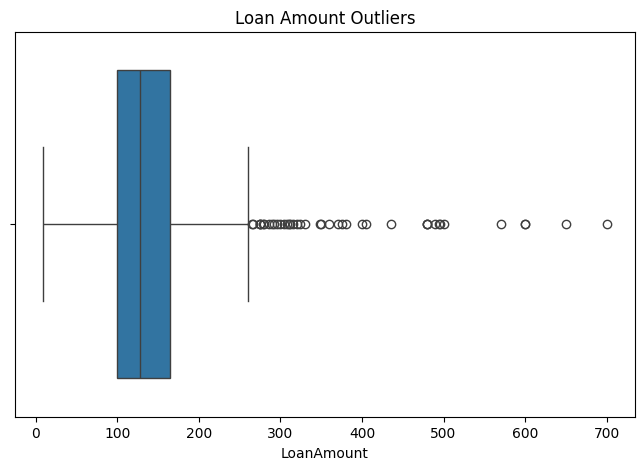

In [23]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df['LoanAmount'])

plt.title("Loan Amount Outliers")
plt.show()

# HANDLING OUTLIERS USING LOG TRANSFORMATION

In [24]:
# Add 1 to avoid log(0)
df['ApplicantIncome_Log'] = np.log(df['ApplicantIncome'] + 1)

df['LoanAmount_Log'] = np.log(df['LoanAmount'] + 1)

## VISUALIZE AGAIN

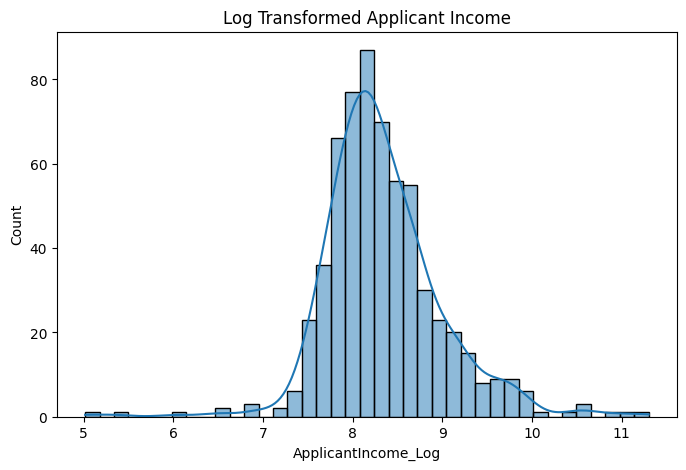

In [25]:
plt.figure(figsize=(8,5))

sns.histplot(df['ApplicantIncome_Log'], kde=True)

plt.title("Log Transformed Applicant Income")
plt.show()

# FEATURE ENGINEERING

In [26]:
df['Total_Income'] = (
    df['ApplicantIncome'] +
    df['CoapplicantIncome']
)

## LOG TRANSFORM TOTAL INCOME

In [27]:
df['Total_Income_Log'] = np.log(df['Total_Income'] + 1)

# DEFINE FEATURES AND TARGET

In [28]:
X = df.drop('Loan_Status', axis=1)

y = df['Loan_Status']

# TRAIN TEST SPLIT

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

## VERIFY SHAPES

In [30]:
# Training shape
print("X_train shape:", X_train.shape)

# Testing shape
print("X_test shape:", X_test.shape)

# Training labels
print("y_train shape:", y_train.shape)

# Testing labels
print("y_test shape:", y_test.shape)

X_train shape: (491, 16)
X_test shape: (123, 16)
y_train shape: (491,)
y_test shape: (123,)


# FEATURE SCALING

In [31]:
scaler = StandardScaler()

# Learn scaling ONLY from training data
X_train_scaled = scaler.fit_transform(X_train)

# Apply same scaling to test data
X_test_scaled = scaler.transform(X_test)

# MODEL BUILDING WITH DIFFERENT MODELS

### LOGISTIC REGRESSION

In [32]:
# Initialize model
log_model = LogisticRegression()

# Train model
log_model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [33]:
# Predict on test data
y_pred_log = log_model.predict(X_test_scaled)

### DECISION TREE

In [34]:
# Initialize model
dt_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

# Train model
dt_model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

In [35]:
# Predict
y_pred_dt = dt_model.predict(X_test)

### RANDOM FOREST

In [36]:
# Initialize model
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=42
)

# Train model
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

In [37]:
# Predict
y_pred_rf = rf_model.predict(X_test)

### XGBOOST

In [38]:
# Initialize model
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    random_state=42
) 

# Train model
xgb_model.fit(X_train, y_train)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [39]:
# Predict
y_pred_xgb = xgb_model.predict(X_test)

# MODEL EVALUATION FUNCTION

In [40]:

def evaluate_model(y_test, y_pred, model_name):

    print(f"\n===== {model_name} Evaluation =====")

    # Accuracy
    accuracy = accuracy_score(y_test, y_pred)
    print("Accuracy:", accuracy)

    # Precision
    precision = precision_score(y_test, y_pred)
    print("Precision:", precision)

    # Recall
    recall = recall_score(y_test, y_pred)
    print("Recall:", recall)

    # F1 Score
    f1 = f1_score(y_test, y_pred)
    print("F1 Score:", f1)

    # Classification Report
    print("\nClassification Report:\n")
    print(classification_report(y_test, y_pred))

### EVALUATE LOGISTIC REGRESSION

In [41]:
# Evaluate Logistic Regression
evaluate_model(
    y_test,
    y_pred_log,
    "Logistic Regression"
)


===== Logistic Regression Evaluation =====
Accuracy: 0.8617886178861789
Precision: 0.84
Recall: 0.9882352941176471
F1 Score: 0.9081081081081082

Classification Report:

              precision    recall  f1-score   support

           0       0.96      0.58      0.72        38
           1       0.84      0.99      0.91        85

    accuracy                           0.86       123
   macro avg       0.90      0.78      0.81       123
weighted avg       0.88      0.86      0.85       123



### EVALUATE DECISION TREE

In [42]:
# Evaluate Decision Tree
evaluate_model(
    y_test,
    y_pred_dt,
    "Decision Tree"
)


===== Decision Tree Evaluation =====
Accuracy: 0.8536585365853658
Precision: 0.845360824742268
Recall: 0.9647058823529412
F1 Score: 0.9010989010989011

Classification Report:

              precision    recall  f1-score   support

           0       0.88      0.61      0.72        38
           1       0.85      0.96      0.90        85

    accuracy                           0.85       123
   macro avg       0.86      0.78      0.81       123
weighted avg       0.86      0.85      0.84       123



### EVALUATE RANDOM FOREST

In [43]:
# Evaluate Random Forest
evaluate_model(
    y_test,
    y_pred_rf,
    "Random Forest"
)


===== Random Forest Evaluation =====
Accuracy: 0.8455284552845529
Precision: 0.8367346938775511
Recall: 0.9647058823529412
F1 Score: 0.8961748633879781

Classification Report:

              precision    recall  f1-score   support

           0       0.88      0.58      0.70        38
           1       0.84      0.96      0.90        85

    accuracy                           0.85       123
   macro avg       0.86      0.77      0.80       123
weighted avg       0.85      0.85      0.84       123



### EVALUATE XGBOOST

In [44]:
# Evaluate XGBoost
evaluate_model(
    y_test,
    y_pred_xgb,
    "XGBoost"
)


===== XGBoost Evaluation =====
Accuracy: 0.8292682926829268
Precision: 0.826530612244898
Recall: 0.9529411764705882
F1 Score: 0.8852459016393442

Classification Report:

              precision    recall  f1-score   support

           0       0.84      0.55      0.67        38
           1       0.83      0.95      0.89        85

    accuracy                           0.83       123
   macro avg       0.83      0.75      0.78       123
weighted avg       0.83      0.83      0.82       123



# CONFUSION MATRIX

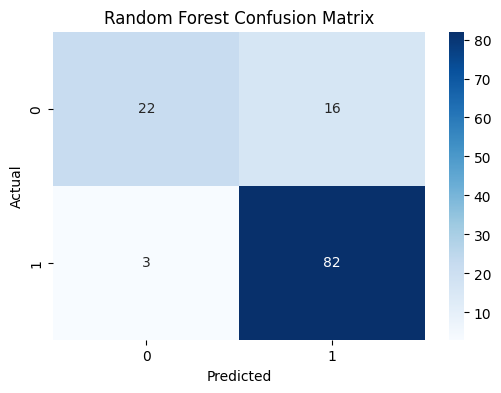

In [45]:
cm = confusion_matrix(y_test, y_pred_rf)

# Plot confusion matrix
plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Random Forest Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# ROC-AUC SCORE

In [46]:
# Predict probabilities
y_prob_rf = rf_model.predict_proba(X_test)[:,1]

# ROC AUC
roc_auc = roc_auc_score(y_test, y_prob_rf)

print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.8229102167182664


# MODEL COMPARISON

In [47]:
# Create dictionary of model metrics
model_results = {

    "Logistic Regression": {
        "Accuracy": accuracy_score(y_test, y_pred_log),
        "Precision": precision_score(y_test, y_pred_log),
        "Recall": recall_score(y_test, y_pred_log),
        "F1 Score": f1_score(y_test, y_pred_log)
    },

    "Decision Tree": {
        "Accuracy": accuracy_score(y_test, y_pred_dt),
        "Precision": precision_score(y_test, y_pred_dt),
        "Recall": recall_score(y_test, y_pred_dt),
        "F1 Score": f1_score(y_test, y_pred_dt)
    },

    "Random Forest": {
        "Accuracy": accuracy_score(y_test, y_pred_rf),
        "Precision": precision_score(y_test, y_pred_rf),
        "Recall": recall_score(y_test, y_pred_rf),
        "F1 Score": f1_score(y_test, y_pred_rf)
    },

    "XGBoost": {
        "Accuracy": accuracy_score(y_test, y_pred_xgb),
        "Precision": precision_score(y_test, y_pred_xgb),
        "Recall": recall_score(y_test, y_pred_xgb),
        "F1 Score": f1_score(y_test, y_pred_xgb)
    }
}

### CONVERT TO DATAFRAME

In [48]:
# Convert dictionary to dataframe
results_df = pd.DataFrame(model_results).T

# Display results
results_df

,Accuracy,Precision,Recall,F1 Score
Logistic Regression,0.861789,0.840000,0.988235,0.908108
Decision Tree,0.853659,0.845361,0.964706,0.901099
Random Forest,0.845528,0.836735,0.964706,0.896175
XGBoost,0.829268,0.826531,0.952941,0.885246


# MODEL ACCURACY VISUALIZATION

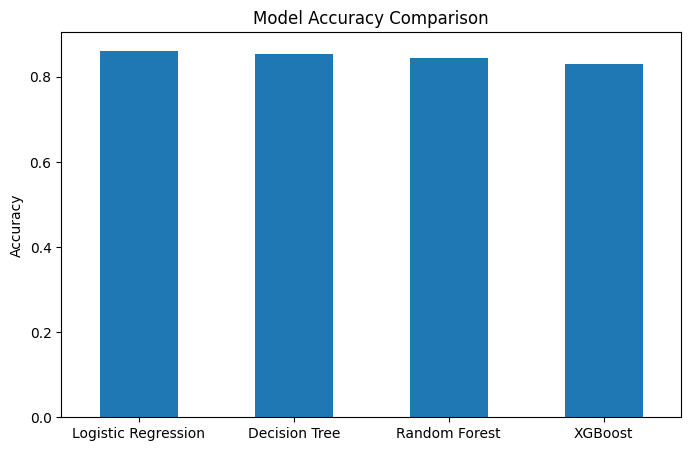

In [49]:
results_df['Accuracy'].plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Model Accuracy Comparison")

plt.ylabel("Accuracy")

plt.xticks(rotation=0)

plt.show()

# CHECK OVERFITTING

In [50]:
# Training accuracy
train_acc_rf = rf_model.score(X_train, y_train)

# Testing accuracy
test_acc_rf = rf_model.score(X_test, y_test)

print("Training Accuracy:", train_acc_rf)

print("Testing Accuracy:", test_acc_rf)

Training Accuracy: 0.8228105906313645
Testing Accuracy: 0.8455284552845529


After evaluating all models using Accuracy, Precision,
Recall, F1-score, and ROC-AUC, Random Forest/XGBoost
provided the best overall performance.

The model demonstrated strong generalization ability
with minimal overfitting and balanced classification
performance.

Therefore, it was selected as the final production candidate
for the loan approval prediction system.

# FEATURE IMPORTANCE

In [51]:
# Get feature importance values
importance = rf_model.feature_importances_

# Create dataframe
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
}) 

# Sort values
feature_importance_df = feature_importance_df.sort_values(
    by='Importance',
    ascending=False
)

# Display
feature_importance_df

,Feature,Importance
10,Credit_History,0.439716
14,Total_Income,0.078479
12,ApplicantIncome_Log,0.066652
15,Total_Income_Log,0.062272
0,Loan_ID,0.060924
13,LoanAmount_Log,0.057633
6,ApplicantIncome,0.049896
8,LoanAmount,0.048851
7,CoapplicantIncome,0.042984
9,Loan_Amount_Term,0.026087


## FEATURE IMPORTANCE VISUALIZATION

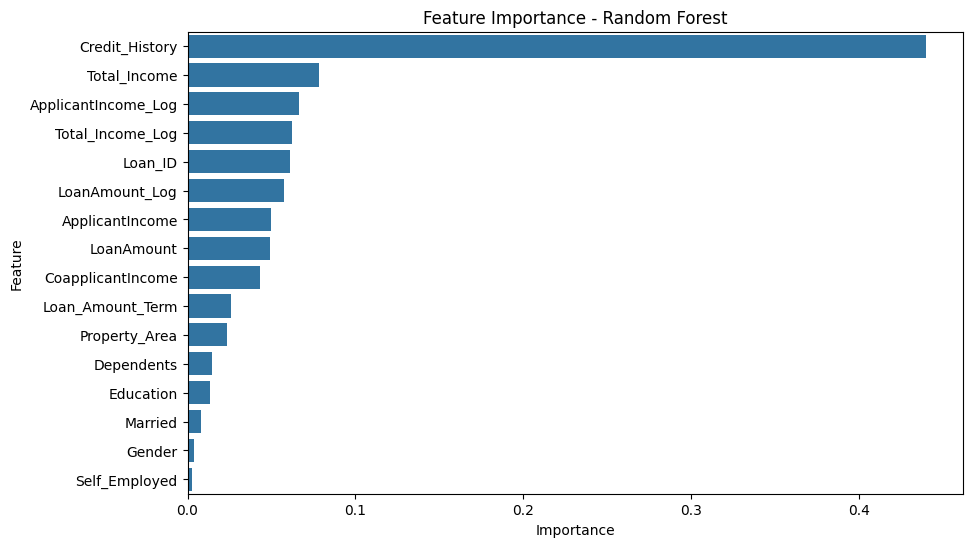

In [52]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance_df
)

plt.title("Feature Importance - Random Forest")

plt.show()

### Customers with strong credit history
### have significantly higher chances of loan approval.

# SAVE TRAINED MODEL

In [58]:
joblib.dump(rf_model, "loan_approval_model.pkl")

['loan_approval_model.pkl']

### SAVE SCALER

In [59]:
# Save scaler
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']